<a href="https://colab.research.google.com/github/mnzsdebora/Projeto-Previs-o-de-Vendas/blob/main/an%C3%A1lise_de_revis%C3%A3o_de_receita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

Leitura e Tratamento dos Dados

In [4]:
# Carregando o dataset de vendas de suplementos
df = pd.read_csv('/content/Supplement_Sales_Weekly_Expanded.csv')

In [5]:
df

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


In [6]:
# Visualizando a estrutura do dataset:
# tipos de dados, colunas e possíveis valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


In [7]:
# Verificando se existem linhas duplicadas que possam distorcer as análises
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Units Sold,Price,Revenue,Discount,Units Returned
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,150.200274,34.781229,5226.569446,0.124398,1.531478
std,12.396099,14.198309,2192.491946,0.071792,1.258479
min,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,158.000000,46.712500,7009.960000,0.190000,2.000000
max,194.000000,59.970000,10761.850000,0.250000,8.000000


In [9]:
#Organizando a Tabela
df = df.rename (columns={
    'Date': 'Data',
    'Product Name':'Produto',
    'Category': 'Categoria',
    'Units Sold': 'Unidades Vendidas',
    'Price' : 'Preço',
    'Revenue': 'Receita',
    'Discount' : 'Desconto',
    'Units Returned': 'Unidades Devolvidas',
    'Location': 'Localização',
    'Platform': 'Plataforma'})
df

,Data,Produto,Categoria,Unidades Vendidas,Preço,Receita,Desconto,Unidades Devolvidas,Localização,Plataforma
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,Sleep Aid,160,47.79,7646.40,0.21,1,USA,iHerb
4380,2025-03-31,Biotin,Vitamin,154,38.12,5870.48,0.22,1,UK,Walmart
4381,2025-03-31,Green Tea Extract,Fat Burner,139,20.40,2835.60,0.12,3,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


In [10]:
df['Categoria'] = df['Categoria'].replace ({
    'Protein': 'Proteína',
    'Vitamin':'Vitamina',
    'Performance': 'Performace',
    'Amino Acid': 'Aminoácido',
    'Sleep Aid': 'auxiliar de sono',
    'Fat Burner': 'Queima de gordura',
    'Hydration': 'Hidratação',})
df

,Data,Produto,Categoria,Unidades Vendidas,Preço,Receita,Desconto,Unidades Devolvidas,Localização,Plataforma
0,2020-01-06,Whey Protein,Proteína,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamina,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamina,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performace,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...
4379,2025-03-31,Melatonin,auxiliar de sono,160,47.79,7646.40,0.21,1,USA,iHerb
4380,2025-03-31,Biotin,Vitamina,154,38.12,5870.48,0.22,1,UK,Walmart
4381,2025-03-31,Green Tea Extract,Queima de gordura,139,20.40,2835.60,0.12,3,USA,iHerb
4382,2025-03-31,Iron Supplement,Mineral,154,18.31,2819.74,0.23,2,Canada,Amazon


In [11]:
#Adicionando novas colunas para seprar a data em dia, mes, ano:
df['Data'] = pd.to_datetime(df['Data'], format='%Y-%m-%d')
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia'] = df['Data'].dt.day

In [12]:
df.head()

,Data,Produto,Categoria,Unidades Vendidas,Preço,Receita,Desconto,Unidades Devolvidas,Localização,Plataforma,Ano,Mes,Dia
0,2020-01-06,Whey Protein,Proteína,143,31.98,4573.14,0.03,2,Canada,Walmart,2020,1,6
1,2020-01-06,Vitamin C,Vitamina,139,42.51,5908.89,0.04,0,UK,Amazon,2020,1,6
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,2020,1,6
3,2020-01-06,Multivitamin,Vitamina,140,16.07,2249.80,0.08,0,Canada,Walmart,2020,1,6
4,2020-01-06,Pre-Workout,Performace,157,35.47,5568.79,0.25,3,Canada,iHerb,2020,1,6


In [13]:
#Reordenando as colunas:
df.insert(0, 'Ano', df.pop('Ano'))
df.insert(1, 'Mes', df.pop('Mes'))
df.insert(2, 'Dia', df.pop('Dia'))

In [14]:
df.head()

,Ano,Mes,Dia,Data,Produto,Categoria,Unidades Vendidas,Preço,Receita,Desconto,Unidades Devolvidas,Localização,Plataforma
0,2020,1,6,2020-01-06,Whey Protein,Proteína,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020,1,6,2020-01-06,Vitamin C,Vitamina,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020,1,6,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020,1,6,2020-01-06,Multivitamin,Vitamina,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020,1,6,2020-01-06,Pre-Workout,Performace,157,35.47,5568.79,0.25,3,Canada,iHerb


In [15]:
#Objetivo incial: Observar as tendencias de vendas de suplementos por ano.
agrupado_empresa = (
    df.groupby(['Ano', 'Plataforma'])['Receita']
    .sum()
    .reset_index())
agrupado_empresa

,Ano,Plataforma,Receita
0,2020,Amazon,1574643.60
1,2020,Walmart,1163234.18
2,2020,iHerb,1585515.44
3,2021,Amazon,1306556.53
4,2021,Walmart,1476022.33
5,2021,iHerb,1511669.31
6,2022,Amazon,1415203.28
7,2022,Walmart,1592276.26
8,2022,iHerb,1365329.01
9,2023,Amazon,1572885.49


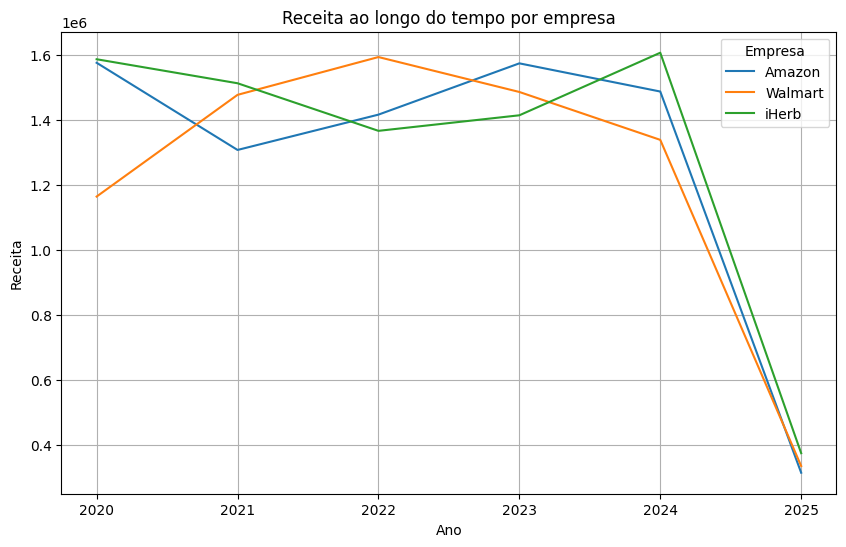

In [16]:
#Receitas em cada ano, por empresa.

plt.figure(figsize=(10, 6))

for empresa in agrupado_empresa['Plataforma'].unique():
    dados = agrupado_empresa[agrupado_empresa['Plataforma'] == empresa]
    plt.plot(dados['Ano'], dados['Receita'], label=empresa)

plt.xlabel('Ano')
plt.ylabel('Receita')
plt.title('Receita ao longo do tempo por empresa')
plt.legend(title='Empresa')
plt.grid(True)
plt.show()

Os dados de 2025 estão disponíveis apenas até o mês de maio. Para evitar distorções e variações abruptas no gráfico, esses registros não serão utilizados na análise visual. Assim, criaremos uma nova tabela excluindo os dados de 2025.

In [17]:
df_limpo =  df[df['Ano'] != 2025]
df_limpo

,Ano,Mes,Dia,Data,Produto,Categoria,Unidades Vendidas,Preço,Receita,Desconto,Unidades Devolvidas,Localização,Plataforma
0,2020,1,6,2020-01-06,Whey Protein,Proteína,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020,1,6,2020-01-06,Vitamin C,Vitamina,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020,1,6,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020,1,6,2020-01-06,Multivitamin,Vitamina,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020,1,6,2020-01-06,Pre-Workout,Performace,157,35.47,5568.79,0.25,3,Canada,iHerb
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4171,2024,12,30,2024-12-30,Melatonin,auxiliar de sono,156,27.81,4338.36,0.07,2,Canada,iHerb
4172,2024,12,30,2024-12-30,Biotin,Vitamina,144,20.37,2933.28,0.10,0,USA,iHerb
4173,2024,12,30,2024-12-30,Green Tea Extract,Queima de gordura,183,55.67,10187.61,0.11,1,Canada,Walmart
4174,2024,12,30,2024-12-30,Iron Supplement,Mineral,140,44.28,6199.20,0.12,0,USA,iHerb


In [18]:
agrupado_empresa = (
    df_limpo.groupby(['Ano', 'Plataforma'])['Receita']
    .sum()
    .reset_index())
agrupado_empresa

,Ano,Plataforma,Receita
0,2020,Amazon,1574643.60
1,2020,Walmart,1163234.18
2,2020,iHerb,1585515.44
3,2021,Amazon,1306556.53
4,2021,Walmart,1476022.33
5,2021,iHerb,1511669.31
6,2022,Amazon,1415203.28
7,2022,Walmart,1592276.26
8,2022,iHerb,1365329.01
9,2023,Amazon,1572885.49


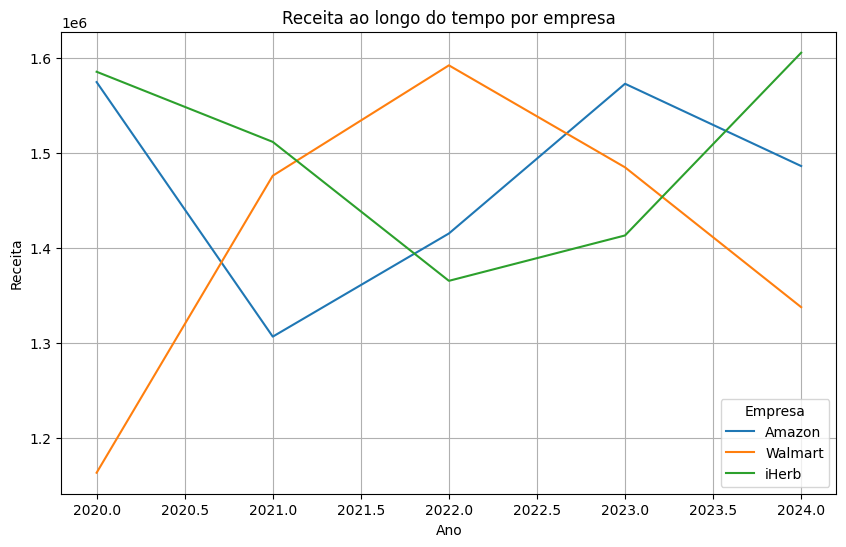

In [19]:
#Plotando novamente o gráfico por ano sem os dados de 2025:
plt.figure(figsize=(10, 6))

for empresa in agrupado_empresa['Plataforma'].unique():
    dados = agrupado_empresa[agrupado_empresa['Plataforma'] == empresa]
    plt.plot(dados['Ano'], dados['Receita'], label=empresa)

plt.xlabel('Ano')
plt.ylabel('Receita')
plt.title('Receita ao longo do tempo por empresa')
plt.legend(title='Empresa')
plt.grid(True)
plt.show()

In [20]:
#Análise dos dados do Walmart nesse inicio de 2020:
df[df['Plataforma'] == 'Walmart']['Ano'].value_counts().sort_index()

,count
Ano,
2020,220
2021,290
2022,301
2023,274
2024,261
2025,66


In [21]:
#Analisando as vendas e os preços médios:
df.groupby(['Plataforma', 'Ano']).agg(
    receita=('Receita', 'sum'),
    quantidade=('Unidades Vendidas', 'sum'),
    preco_medio=('Preço', 'mean')
).reset_index()

,Plataforma,Ano,receita,quantidade,preco_medio
0,Amazon,2020,1574643.60,45999,34.195081
1,Amazon,2021,1306556.53,37661,34.652778
2,Amazon,2022,1415203.28,40391,34.974481
3,Amazon,2023,1572885.49,43715,35.935959
4,Amazon,2024,1486213.90,42543,34.889753
5,Amazon,2025,313948.98,10314,30.491594
6,Walmart,2020,1163234.18,32785,35.591000
7,Walmart,2021,1476022.33,43505,33.939724
8,Walmart,2022,1592276.26,45414,34.935083
9,Walmart,2023,1484853.82,41400,35.899781


In [22]:
#Em 2020, o Walmart estava concentrado em poucos países/regiões?
df[(df['Plataforma'] == 'Walmart') & (df['Ano'] == 2020)]['Localização'].value_counts()

,count
Localização,
UK,82
Canada,70
USA,68


In [23]:
df_walmart = df_limpo[df_limpo['Plataforma'] == 'Walmart']

In [24]:
receita_walmart = (
    df_walmart
        .groupby('Mes')['Receita']
        .sum()
        .reset_index()
)

In [25]:
#Crescimento relativo:
receita_walmart['crescimento_%'] = receita_walmart['Receita'].pct_change() * 100
receita_walmart

,Mes,Receita,crescimento_%
0,1,624448.65,NaN
1,2,619338.12,-0.818407
2,3,563970.31,-8.939836
3,4,572651.73,1.539340
4,5,545167.15,-4.799528
5,6,646315.56,18.553651
6,7,566025.47,-12.422738
7,8,641607.81,13.353169
8,9,523272.07,-18.443625
9,10,584515.55,11.703946


Com isso, podemos interpretar que o Walmart começou com oscilações típicas de entrada no mercado antes de atingir maior estabilidade ao longo do tempo.

### Gráficos dos crescimentos de cada plataforma:

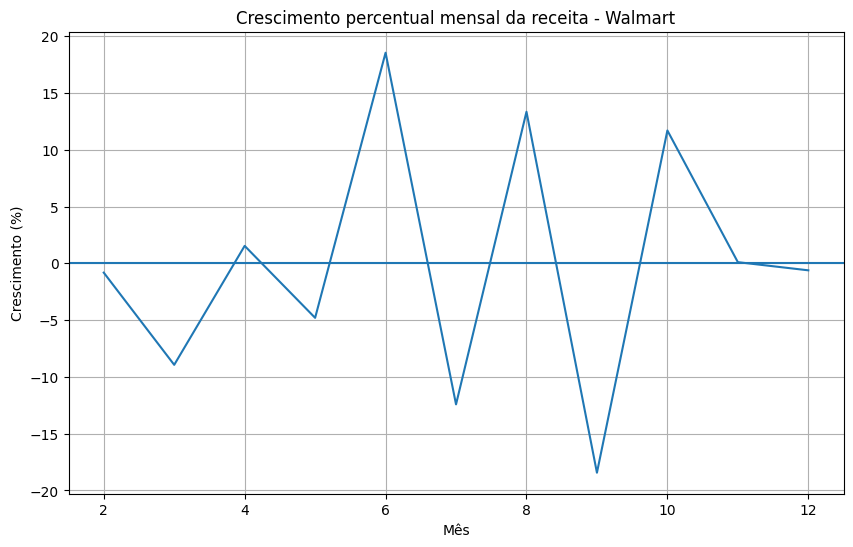

In [26]:
#Gráfico só com os crescimentos:
plt.figure(figsize=(10,6))
plt.plot(receita_walmart['Mes'], receita_walmart['crescimento_%'])
plt.axhline(0)
plt.xlabel('Mês')
plt.ylabel('Crescimento (%)')
plt.title('Crescimento percentual mensal da receita - Walmart')
plt.grid(True)
plt.show()

Os picos demonstram potencial de expansão, que se estabiliza nos meses finais.
Esse padrão nos revela:

*  O walmart consegue crescer rápido mas não sustenta o crescimento por varios períodos.
*   A queda pode se dar por várias causas, dentre elas a sazonalidade, a falta de propagandas e engajamento para impulsionar vendas e fatores externos.


---




Comparando com as outras plataformas e observar esse desenvolvimento


In [27]:
df[df['Plataforma'] == 'Amazon']['Ano'].value_counts().sort_index()

,count
Ano,
2020,307
2021,252
2022,270
2023,292
2024,283
2025,69


In [28]:
df_amazon = df_limpo[df_limpo['Plataforma'] == 'Amazon']

In [29]:
receita_amazon = (
    df_amazon
        .groupby('Mes')['Receita']
        .sum()
        .reset_index()
)

In [30]:
receita_amazon = receita_amazon.sort_values('Mes')

In [31]:
receita_amazon['crescimento_%'] = (
    receita_amazon['Receita'].pct_change() * 100
)
receita_amazon

,Mes,Receita,crescimento_%
0,1,611260.77,NaN
1,2,518890.83,-15.111380
2,3,641987.61,23.723059
3,4,567128.68,-11.660495
4,5,681238.99,20.120709
5,6,588702.31,-13.583585
6,7,629290.06,6.894444
7,8,629332.87,0.006803
8,9,627460.67,-0.297490
9,10,576364.40,-8.143342


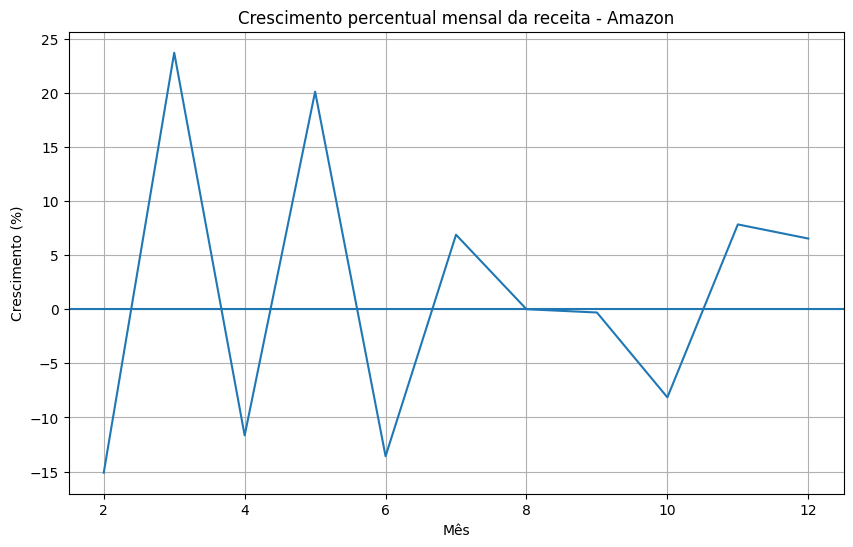

In [32]:
plt.figure(figsize=(10,6))
plt.plot(receita_amazon['Mes'], receita_amazon['crescimento_%'])
plt.axhline(0)
plt.xlabel('Mês')
plt.ylabel('Crescimento (%)')
plt.title('Crescimento percentual mensal da receita - Amazon')
plt.grid(True)
plt.show()

A amazon alterna menos entre extremos, recupera quedas mais rapidamentem e entra em estabilidade mais cedo.







In [33]:
df[df['Plataforma'] == 'iHerb']['Ano'].value_counts().sort_index()

,count
Ano,
2020,305
2021,290
2022,261
2023,266
2024,304
2025,73


In [34]:
df_iHerb = df_limpo[df_limpo['Plataforma'] == 'iHerb']

In [35]:
receita_iHerb = (
    df_iHerb
        .groupby('Mes')['Receita']
        .sum()
        .reset_index()
)

In [36]:
receita_iHerb = receita_iHerb.sort_values('Mes')

In [37]:
receita_iHerb['crescimento_%'] = (
    receita_iHerb['Receita'].pct_change() * 100
)
receita_iHerb

,Mes,Receita,crescimento_%
0,1,631291.48,NaN
1,2,593049.64,-6.057715
2,3,689209.47,16.214466
3,4,545881.89,-20.795939
4,5,693675.07,27.074205
5,6,591859.53,-14.677699
6,7,654116.31,10.518844
7,8,655050.90,0.142878
8,9,631704.86,-3.564004
9,10,655161.21,3.713182


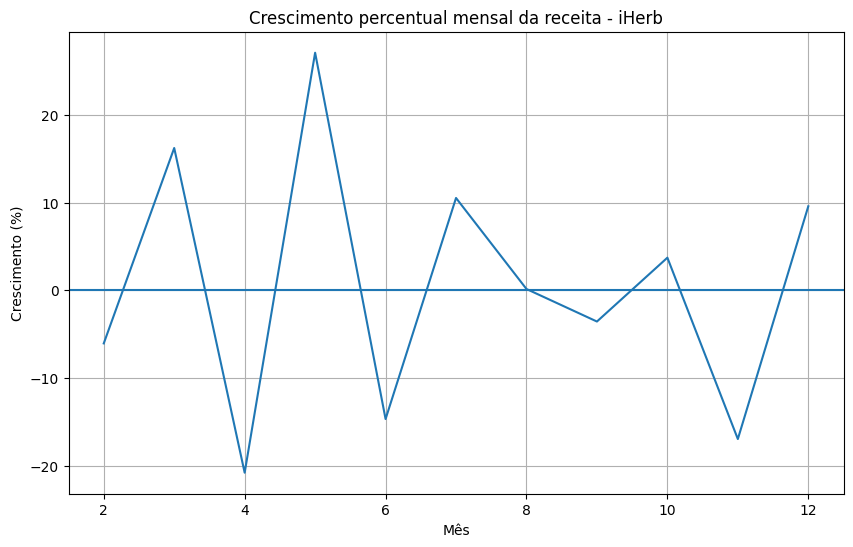

In [38]:
plt.figure(figsize=(10,6))
plt.plot(receita_iHerb['Mes'], receita_iHerb['crescimento_%'])
plt.axhline(0)
plt.xlabel('Mês')
plt.ylabel('Crescimento (%)')
plt.title('Crescimento percentual mensal da receita - iHerb')
plt.grid(True)
plt.show()

Aqui vemos que o iHerb também tem picos e baixas, mas também possui uma constancia maior.

### Após analisar como as plataformas se comportam ao longo dos meses, vamos utilizar o Walmart para prever a receita de 2024, a fim de verificar como o modelo se comporta e também realizar uma validação mais controlada. Ao prever 2024, ano no qual já temos os valores reais, conseguimos medir os erros e, assim, ter uma base mais sólida para a projeção de 2025.

#Pré-processanmento e Previsão de Vendas

In [39]:
df['Data'] = pd.to_datetime(df['Data'])
df_walmart = df[df['Plataforma'] == 'Walmart'].copy()
df_walmart = df_walmart.sort_values('Data')

In [40]:
df_walmart_mensal = (
    df_walmart
        .groupby(pd.Grouper(key='Data', freq='M'))['Receita']
        .sum()
        .reset_index()
)

/tmp/ipython-input-417/1140383177.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='Data', freq='M'))['Receita']


In [41]:
df_walmart_mensal['ano'] = df_walmart_mensal['Data'].dt.year
df_walmart_mensal['mes'] = df_walmart_mensal['Data'].dt.month
df_walmart_mensal

,Data,Receita,ano,mes
0,2020-01-31,83794.97,2020,1
1,2020-02-29,58917.85,2020,2
2,2020-03-31,85968.10,2020,3
3,2020-04-30,126324.66,2020,4
4,2020-05-31,67817.15,2020,5
...,...,...,...,...
58,2024-11-30,93988.32,2024,11
59,2024-12-31,135876.18,2024,12
60,2025-01-31,114418.10,2025,1
61,2025-02-28,92440.40,2025,2


In [42]:
#Preparar o histórico da receita
df_walmart_mensal['lag_1']  = df_walmart_mensal['Receita'].shift(1)
df_walmart_mensal['lag_3']  = df_walmart_mensal['Receita'].shift(3)
df_walmart_mensal['lag_6']  = df_walmart_mensal['Receita'].shift(6)
df_walmart_mensal['lag_12'] = df_walmart_mensal['Receita'].shift(12)
df_walmart_mensal[['Receita', 'lag_1', 'lag_3', 'lag_6', 'lag_12']].head(10)

,Receita,lag_1,lag_3,lag_6,lag_12
0,83794.97,NaN,NaN,NaN,NaN
1,58917.85,83794.97,NaN,NaN,NaN
2,85968.10,58917.85,NaN,NaN,NaN
3,126324.66,85968.10,83794.97,NaN,NaN
4,67817.15,126324.66,58917.85,NaN,NaN
5,149894.91,67817.15,85968.10,NaN,NaN
6,88055.19,149894.91,126324.66,83794.97,NaN
7,131437.30,88055.19,67817.15,58917.85,NaN
8,108236.52,131437.30,149894.91,85968.10,NaN
9,82720.06,108236.52,88055.19,126324.66,NaN


In [43]:
#Limpar dados
df_modelo = df_walmart_mensal.dropna().copy()


In [44]:
#Separando o treino e o teste
train1 = df_modelo[df_modelo['ano'] <= 2023]
test1  = df_modelo[df_modelo['ano'] == 2024]

In [45]:
#definindo x e y
features1 = ['mes', 'lag_1', 'lag_3', 'lag_6', 'lag_12']

X_train1 = train1[features1]
y_train1 = train1['Receita']

X_test1  = test1[features1]
y_test1  = test1['Receita']

In [46]:
#Treinando o Random Forest
rf_model1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [47]:
rf_model1.fit(X_train1, y_train1)

RandomForestRegressor(n_estimators=200, random_state=42)

In [48]:
#Fazer previsoes para 2024
y_pred_rf1 = rf_model1.predict(X_test1)

In [49]:
y_pred_rf1

array([143868.4451 , 125027.14015, 139064.5334 , 134475.56665,
       120245.3848 , 125594.87065, 120390.75225, 123930.4804 ,
       117637.7764 , 135945.29965, 123913.1097 , 134181.3408 ])

In [50]:
mae_rf1 = mean_absolute_error(y_test1, y_pred_rf1)
rmse_rf1 = np.sqrt(mean_squared_error(y_test1, y_pred_rf1))

print(f"Random Forest - MAE:  {mae_rf1:,.2f}")
print(f"Random Forest - RMSE: {rmse_rf1:,.2f}")

Random Forest - MAE:  19,642.91
Random Forest - RMSE: 25,282.84


In [51]:
receita_media1 = y_test1.mean()
erro_percentual1 = mae_rf1 / receita_media1

receita_media1, erro_percentual1

(np.float64(111465.28083333334), np.float64(0.17622445003185147))

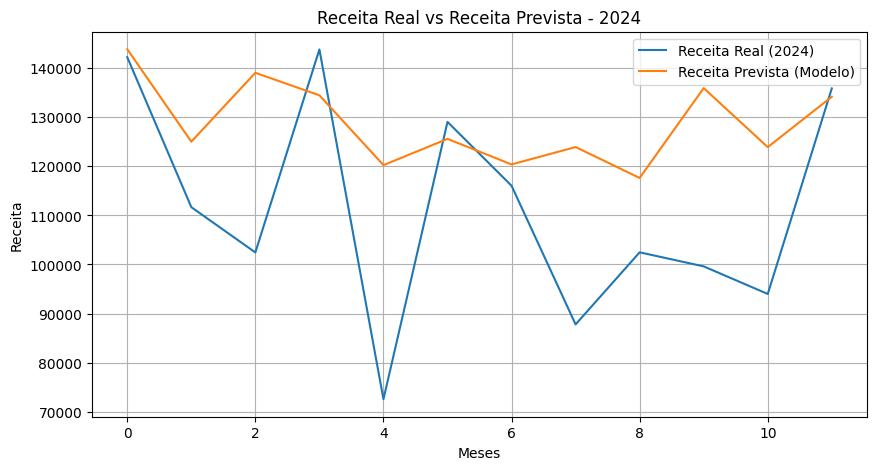

In [52]:
plt.figure(figsize=(10, 5))

plt.plot(y_test1.values, label='Receita Real (2024)')
plt.plot(y_pred_rf1, label='Receita Prevista (Modelo)')

plt.title('Receita Real vs Receita Prevista - 2024')
plt.xlabel('Meses')
plt.ylabel('Receita')
plt.legend()
plt.grid(True)

plt.show()

Melhorando o modelo

In [53]:
#criando médias para suavizar oscilações curtas

df_walmart_mensal['media_3'] = df_walmart_mensal['Receita'].rolling(3).mean()
df_walmart_mensal['media_6'] = df_walmart_mensal['Receita'].rolling(6).mean()

In [54]:
train2 = df_walmart_mensal[df_walmart_mensal['ano'] <= 2023]
test2 = df_walmart_mensal[df_walmart_mensal['ano'] == 2024]

In [55]:
features2 = ['mes', 'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'media_3', 'media_6']

X_train2 = train2[features2]
y_train2 = train2['Receita']

X_test2 = test2[features2]
y_test2 = test2['Receita']


In [56]:
#Melhorando os parâmetros para melhorar os resultados
rf_model2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42
)

rf_model2.fit(X_train2, y_train2)
y_pred2 = rf_model2.predict(X_test2)

In [57]:
mae2 = mean_absolute_error(y_test2, y_pred2)

mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)

erro_pct2 = mae2 / y_test2.mean()

mae2, rmse2, erro_pct2

(14224.368485400155,
 np.float64(17193.979347047643),
 np.float64(0.12761254786294318))

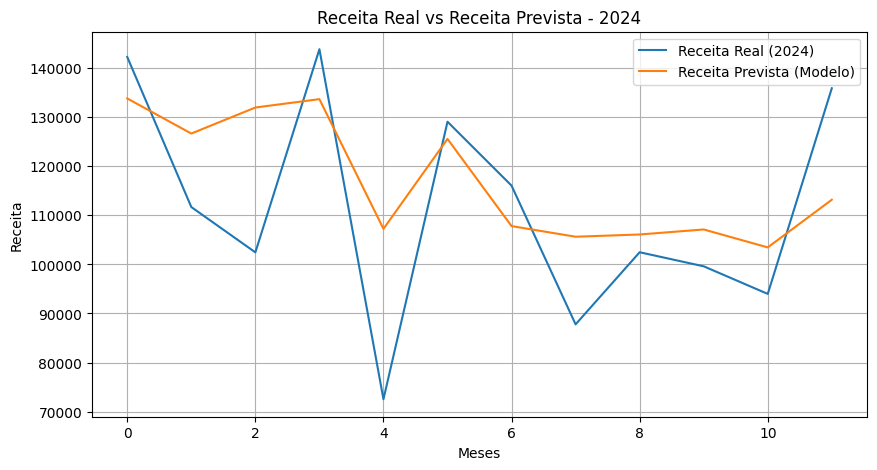

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(y_test2.values, label='Receita Real (2024)')
plt.plot(y_pred2, label='Receita Prevista (Modelo)')

plt.title('Receita Real vs Receita Prevista - 2024')
plt.xlabel('Meses')
plt.ylabel('Receita')
plt.legend()
plt.grid(True)

plt.show()

O gráfico apresenta a comparação entre a receita real observada em 2024 e a receita prevista pelo modelo, mês a mês.
O modelo conseguiu capturar a tendência geral da receita, mantendo valores em uma faixa próxima da realidade ao longo do ano.
No entanto, observa-se que a linha prevista é mais suave do que a linha real. Isso indica que o modelo teve dificuldade em acompanhar variações bruscas.

### Agora, projetamos a receita de 2025 utilizando o modelo Random Forest, mantendo os mesmos parâmetros definidos anteriormente, pois apresentaram desempenho dentro de um nível considerado aceitável na etapa de validação.


In [59]:
for lag in [1,2,3,6,12]:
    df_walmart_mensal[f'lag_{lag}'] = df_walmart_mensal['Receita'].shift(lag)

In [60]:
df_modelo3 = df_walmart_mensal.dropna().copy()

In [61]:
df_treino3 = df_modelo3[df_modelo3['ano'] <= 2024]

features3 = ['lag_1','lag_2','lag_3','lag_6','lag_12']

X_train3 = df_treino3[features3]
y_train3 = df_treino3['Receita']

In [62]:
rf3 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42
)

rf3.fit(X_train3, y_train3)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, random_state=42)

In [63]:
historico = df_modelo3[['mes','Receita']].copy()
historico = historico.sort_values('mes')

In [64]:

datas_2025 = pd.date_range('2025-01-01', '2025-12-01', freq='MS')

previsoes = []

for data in datas_2025:
    linha = {
        'lag_1':  historico.iloc[-1]['Receita'],
        'lag_2':  historico.iloc[-2]['Receita'],
        'lag_3':  historico.iloc[-3]['Receita'],
        'lag_6':  historico.iloc[-6]['Receita'],
        'lag_12': historico.iloc[-12]['Receita'],
    }

    X_pred3 = pd.DataFrame([linha])
    y_pred3 = rf3.predict(X_pred3)[0]

    previsoes.append(y_pred3)

    historico = pd.concat([
        historico,
        pd.DataFrame({'Data':[data], 'Receita':[y_pred3]})
    ], ignore_index=True)

In [65]:
df_previsao_2025 = pd.DataFrame({
    'Data': pd.date_range('2025-01-01', '2025-12-01', freq='MS'),
    'Receita_Prevista': previsoes
})

df_previsao_2025

,Data,Receita_Prevista
0,2025-01-01,126570.982583
1,2025-02-01,129642.290370
2,2025-03-01,120611.701778
3,2025-04-01,129460.554434
4,2025-05-01,128819.719502
5,2025-06-01,124669.931710
6,2025-07-01,133623.155656
7,2025-08-01,131921.191911
8,2025-09-01,134537.377832
9,2025-10-01,123513.739489


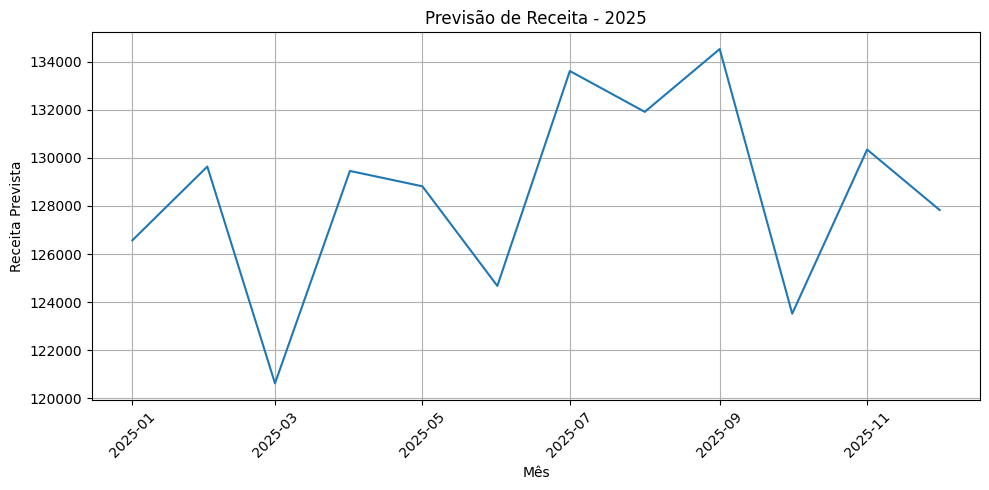

In [66]:
df_previsao_2025['Data'] = pd.to_datetime(df_previsao_2025['Data'])

plt.figure(figsize=(10,5))
plt.plot(df_previsao_2025['Data'],
         df_previsao_2025['Receita_Prevista'],)

plt.title('Previsão de Receita - 2025')
plt.xlabel('Mês')
plt.ylabel('Receita Prevista')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusão do projeto:

O intuito desse projeto foi trabalhar a análise dos dados de receita histórica de diferentes plataformas ao longo dos anos, mais especificamente de 2020 a 2024. Após essa análise e tratamento dos dados, busquei trabalhar algumas projeções de vendas para o próximo ano, a fim de observar comportamentos e avaliar hipóteses que explicassem quedas de receita e também orientar tomadas de decisões para evitá-las.
Assim, o que pude concluir foi que o modelo utilizado se comportou bem, trazendo boas previsões para 2024 (que comparamos com a receita real), e que poderia orientar adequadamente as tomadas de decisões para a plataforma no caso da projeção para 2025. Com isso, é possível se antecipar às quedas e buscar meios de evitá-las.
Além disso, o projeto evidenciou a importância de modelos de Machine Learning como ferramenta estratégica para análise de dados, mostrando que decisões baseadas em dados tendem a ser mais assertivas e fundamentadas.